In [ ]:
# Raisin Detective ML

# Can machine learning detect raisin types based on shape and size?

# Goal:
# Classify raisin types (Kecimen vs Besni) using supervised machine learning.

# Business case:
# Automated food sorting and quality control.

In [37]:
# =========================
# CELL 1: IMPORTS
# =========================
# Syfte:
# Ladda in alla bibliotek vi behöver för:
# - EDA
# - visualisering
# - supervised learning
# - model evaluation
# - feature importance
# - PCA

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

sns.set(style="whitegrid")

In [38]:
# =========================
# CELL 2: LOAD DATA
# =========================
# Frågeställning:
# Vilket dataset arbetar vi med?
#
# Logik:
# Vi använder Path.cwd() för att hitta projektmappen oavsett
# om notebooken körs från /notebooks/spirit eller projektroten.

current_path = Path.cwd()

# Om notebooken ligger i notebooks/spirit går vi upp två nivåer.
# Om notebooken körs från projektroten används current_path direkt.
if current_path.name == "spirit":
    project_folder = current_path.parents[1]
elif current_path.name == "notebooks":
    project_folder = current_path.parent
else:
    project_folder = current_path

csv_path = project_folder / "data" / "raw" / "raisin_dataset.csv"
xlsx_path = project_folder / "data" / "raw" / "Raisin_Dataset.xlsx"

print("Current path:", current_path)
print("Project folder:", project_folder)
print("CSV finns:", csv_path.exists(), csv_path)
print("Excel finns:", xlsx_path.exists(), xlsx_path)

# Läs CSV om den finns, annars Excel
if csv_path.exists():
    df = pd.read_csv(csv_path)
elif xlsx_path.exists():
    df = pd.read_excel(xlsx_path)
else:
    raise FileNotFoundError("Hittar varken raisin_dataset.csv eller Raisin_Dataset.xlsx i data/raw")

df.head()

Current path: c:\Users\spiri\ws\raisin-detective-ml\notebooks\spirit
Project folder: c:\Users\spiri\ws\raisin-detective-ml
CSV finns: False c:\Users\spiri\ws\raisin-detective-ml\data\raw\raisin_dataset.csv
Excel finns: True c:\Users\spiri\ws\raisin-detective-ml\data\raw\Raisin_Dataset.xlsx


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [39]:
# =========================
# CELL 3: BASIC OVERVIEW
# =========================
# Frågeställning:
# Hur ser datasetet ut?
#
# Logik:
# Innan vi tränar modeller måste vi veta:
# - antal rader
# - antal kolumner
# - datatyper
# - numeriska intervall

print("Shape:", df.shape)

print("\nKolumner:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nStatistisk sammanfattning:")
display(df.describe())

Shape: (900, 8)

Kolumner:
['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter', 'Class']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    str    
dtypes: float64(5), int64(2), str(1)
memory usage: 56.4 KB

Statistisk sammanfattning:


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


Missing values:


Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


Class balance:


Class
Kecimen    450
Besni      450
Name: count, dtype: int64

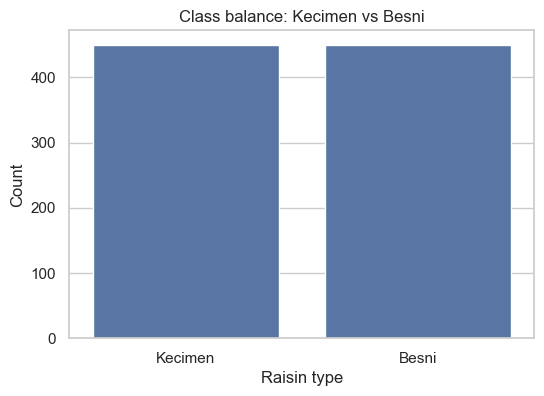

In [40]:
# =========================
# CELL 4: DATA QUALITY + CLASS BALANCE
# =========================
# Frågeställning:
# Är datasetet rent och balanserat?
#
# Logik:
# Missing values kan störa modeller.
# Klassbalans är viktigt eftersom supervised classification annars kan bli missvisande.

print("Missing values:")
display(df.isna().sum())

print("\nClass balance:")
display(df["Class"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Class")
plt.title("Class balance: Kecimen vs Besni")
plt.xlabel("Raisin type")
plt.ylabel("Count")
plt.show()

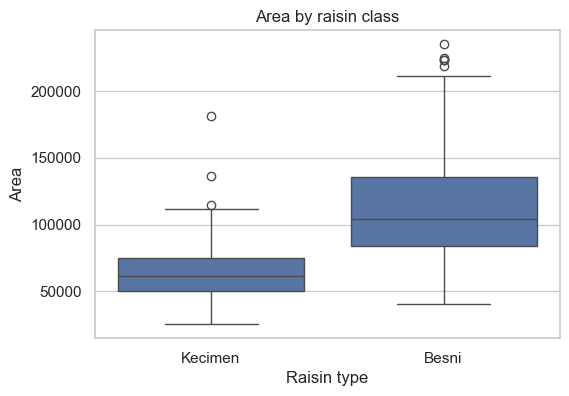

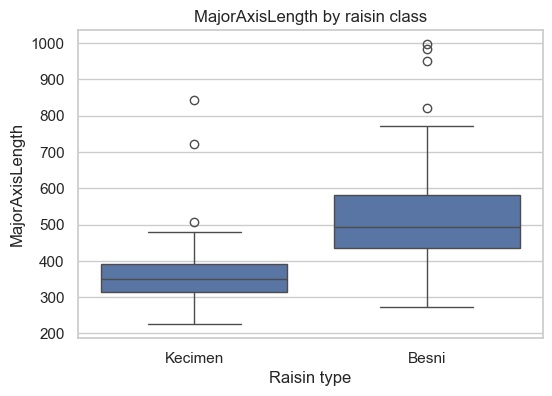

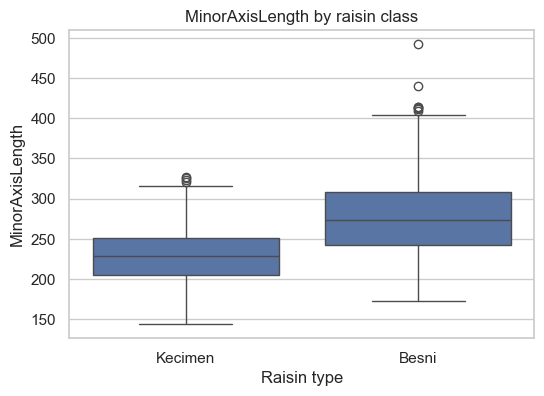

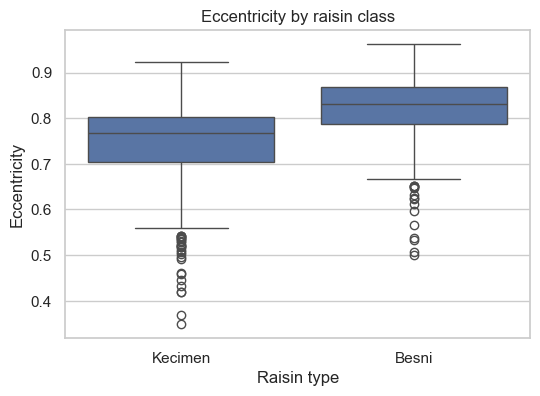

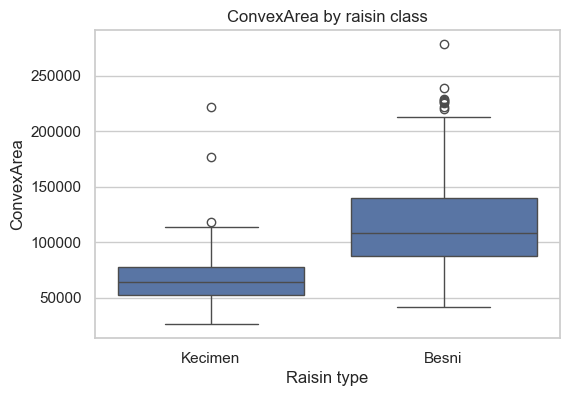

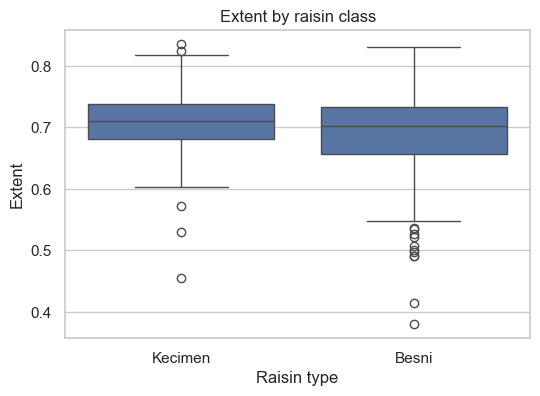

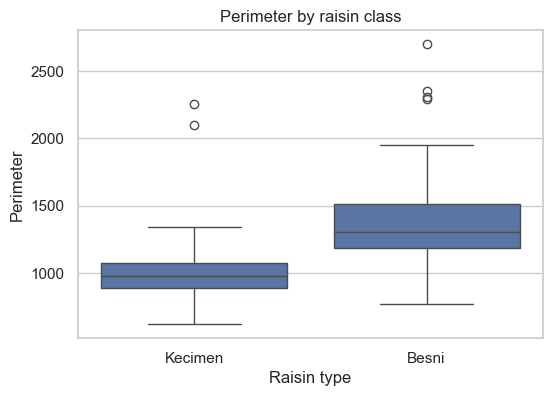

In [41]:
# =========================
# CELL 5: BOXPLOTS BY CLASS
# =========================
# Frågeställning:
# Vilka fysiska egenskaper verkar skilja russinsorterna åt?
#
# Logik:
# Om en feature har tydligt olika nivåer mellan Kecimen och Besni
# kan den vara användbar för modellen.

feature_cols = [col for col in df.columns if col != "Class"]

for col in feature_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Class", y=col)
    plt.title(f"{col} by raisin class")
    plt.xlabel("Raisin type")
    plt.ylabel(col)
    plt.show()

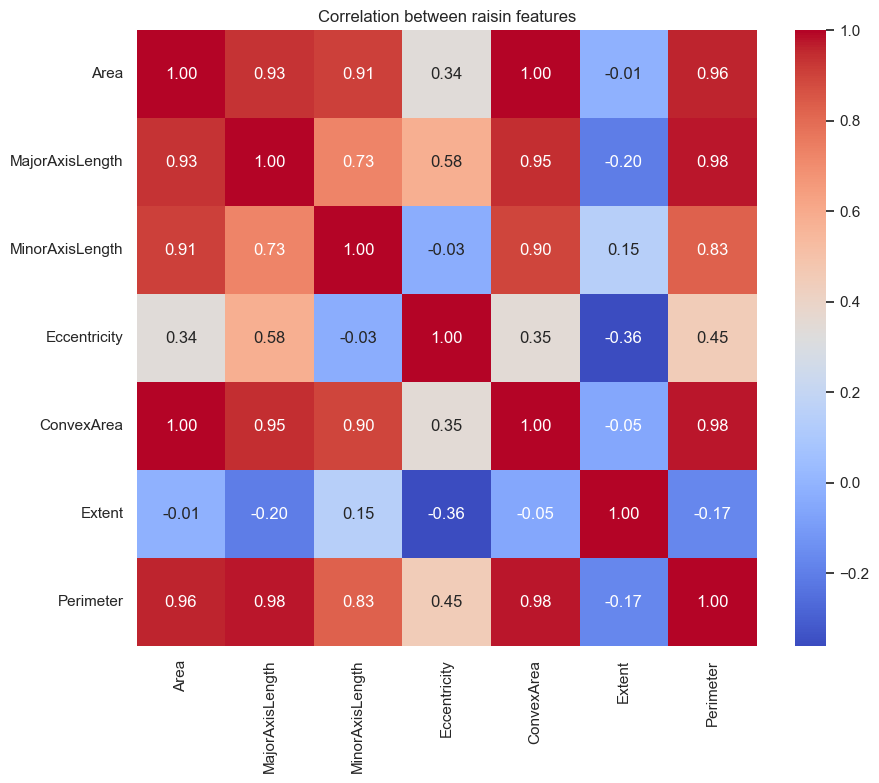

In [42]:
# =========================
# CELL 6: CORRELATION HEATMAP
# =========================
# Frågeställning:
# Vilka variabler hänger ihop?
#
# Logik:
# Många formmått kan vara starkt korrelerade.
# Exempel: Area och ConvexArea kan mäta liknande sak.
# Detta hjälper oss förstå redundans och varför PCA kan vara relevant.

corr = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between raisin features")
plt.show()

In [43]:
# =========================
# CELL 7: TRAIN / TEST SPLIT
# =========================
# Frågeställning:
# Hur delar vi datan rättvist för att testa modellen?
#
# Logik:
# X = features, alltså mätvärdena modellen får använda.
# y = target, alltså russinsorten modellen ska förutsäga.
#
# Vi använder samma split som gruppen:
# test_size=0.2
# random_state=42
# stratify=y
#
# Detta gör resultaten jämförbara mellan gruppmedlemmar.

X = df.drop(columns=["Class"])
y = df["Class"]

# Encode target:
# Kecimen/Besni blir 0/1 så modellerna kan använda target numeriskt.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(label, "=", code)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train class balance:", np.bincount(y_train))
print("y_test class balance:", np.bincount(y_test))

Label mapping:
Besni = 0
Kecimen = 1
X_train: (720, 7)
X_test: (180, 7)
y_train class balance: [360 360]
y_test class balance: [90 90]


In [44]:
# =========================
# CELL 8: EVALUATION FUNCTION
# =========================
# Syfte:
# Slippa skriva om samma utvärderingskod för varje modell.
#
# Logik:
# Vi vill jämföra Decision Tree, Random Forest och XGBoost på samma sätt.

model_results = []

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"===== {model_name} =====")
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print("ROC AUC:", auc)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

    model_results.append({
        "model": model_name,
        "accuracy": acc,
        "f1_score": f1,
        "roc_auc": auc
    })

===== 1 Decision Tree =====
Accuracy: 0.8722222222222222
F1-score: 0.8795811518324608
ROC AUC: 0.902962962962963

Classification report:
              precision    recall  f1-score   support

       Besni       0.92      0.81      0.86        90
     Kecimen       0.83      0.93      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



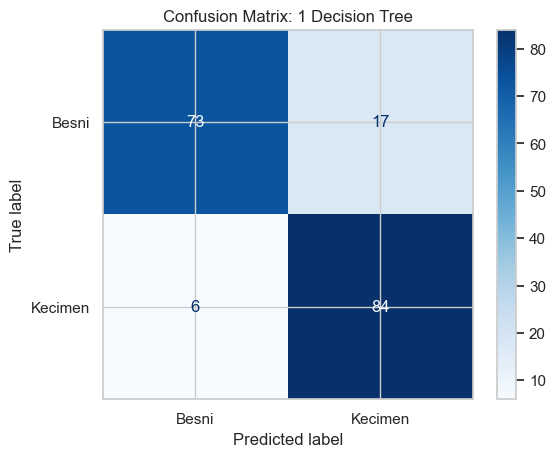

In [109]:
# =========================
# CELL 9: DECISION TREE
# =========================
# Frågeställning:
# Kan en enkel modell skapa tydliga regler för att skilja russinsorterna?
#
# Logik:
# Beslutsträd är pedagogiskt eftersom modellen fungerar som ett flödesschema:
# "Om Area är större än X, gå hit; annars gå dit."

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

evaluate_model("1 Decision Tree", tree_model, X_test, y_test)

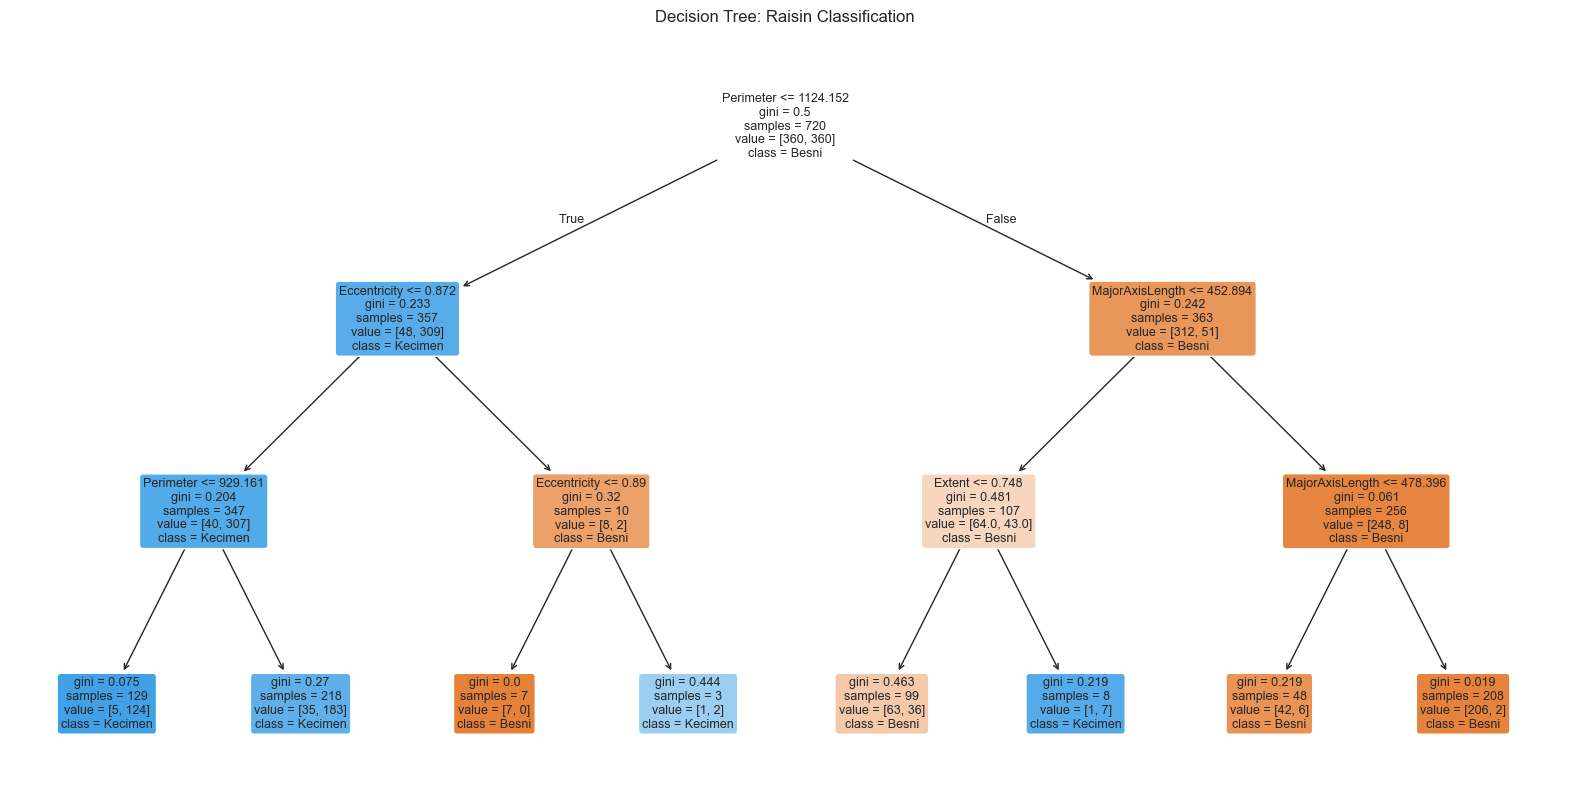

In [110]:
# =========================
# CELL 10: VISUALIZE DECISION TREE
# =========================
# Frågeställning:
# Vilka ja/nej-regler använder modellen?
#
# Logik:
# Detta är bra för presentation eftersom man kan visa hur modellen "tänker".

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree: Raisin Classification")
plt.show()

===== Random Forest =====
Accuracy: 0.8666666666666667
F1-score: 0.8775510204081632
ROC AUC: 0.9219135802469136

Classification report:
              precision    recall  f1-score   support

       Besni       0.95      0.78      0.85        90
     Kecimen       0.81      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



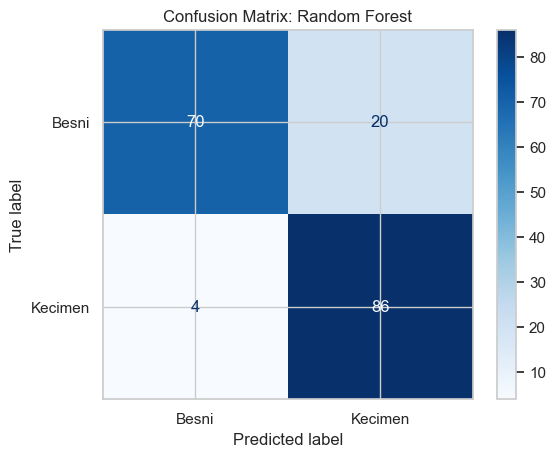

In [111]:
# =========================
# CELL 11: RANDOM FOREST
# =========================
# Frågeställning:
# Blir modellen bättre om många beslutsträd får rösta tillsammans?
#
# Logik:
# Ett enskilt beslutsträd kan överanpassa.
# Random Forest bygger många träd och låter dem rösta.
# Det gör modellen ofta stabilare.

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

evaluate_model("Random Forest", rf_model, X_test, y_test)

===== XGBoost =====
Accuracy: 0.85
F1-score: 0.8615384615384616
ROC AUC: 0.9133333333333333

Classification report:
              precision    recall  f1-score   support

       Besni       0.92      0.77      0.84        90
     Kecimen       0.80      0.93      0.86        90

    accuracy                           0.85       180
   macro avg       0.86      0.85      0.85       180
weighted avg       0.86      0.85      0.85       180



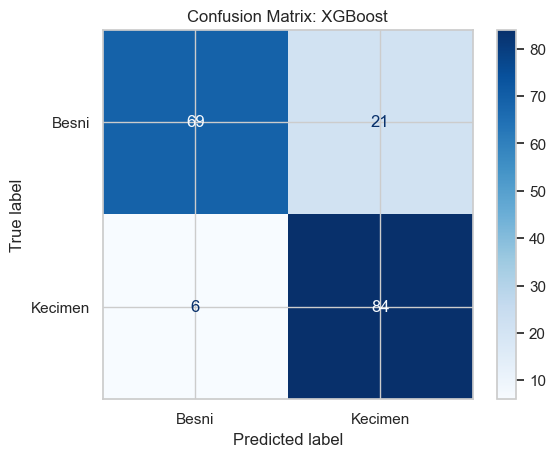

In [112]:
# =========================
# CELL 12: XGBOOST
# =========================
# Frågeställning:
# Kan en mer avancerad ensemblemodell förbättra resultatet?
#
# Logik:
# XGBoost bygger träd stegvis.
# Varje nytt träd försöker rätta till tidigare misstag.

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

evaluate_model("XGBoost", xgb_model, X_test, y_test)

,model,accuracy,f1_score,roc_auc
13,50 Random Forest,0.872222,0.882051,0.921420
4,Simple Random Forest,0.872222,0.882051,0.921420
0,Decision Tree,0.872222,0.879581,0.902963
17,1 Decision Tree,0.872222,0.879581,0.902963
14,200 Random Forest,0.866667,0.877551,0.921543
3,Tuned Random Forest,0.866667,0.877551,0.919691
1,Random Forest,0.866667,0.877551,0.921914
5,Medium Random Forest,0.866667,0.877551,0.921543
10,200 Random Forest,0.866667,0.877551,0.921543
18,Random Forest,0.866667,0.877551,0.921914


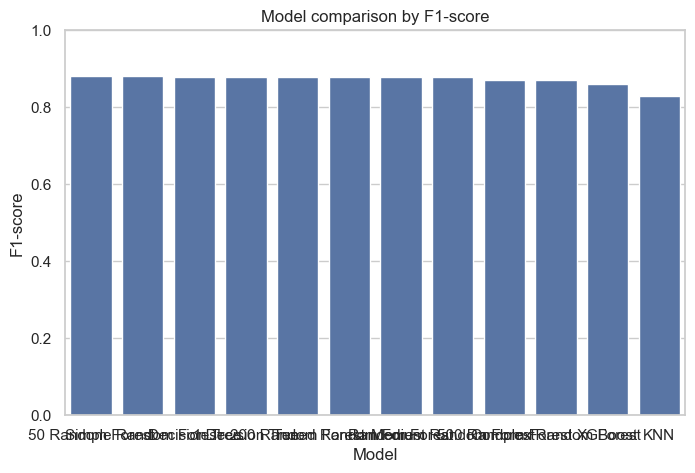

In [113]:
# =========================
# CELL 13: COMPARE MODELS
# =========================
# Frågeställning:
# Vilken modell presterar bäst på testdatan?
#
# Logik:
# Eftersom alla modeller använder samma train/test split
# blir jämförelsen rättvis.

results_df = pd.DataFrame(model_results).sort_values("f1_score", ascending=False)

display(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="model", y="f1_score")
plt.title("Model comparison by F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.show()

Perimeter          0.300281
MajorAxisLength    0.254725
ConvexArea         0.159546
Area               0.131194
Eccentricity       0.068805
MinorAxisLength    0.056612
Extent             0.028838
dtype: float64

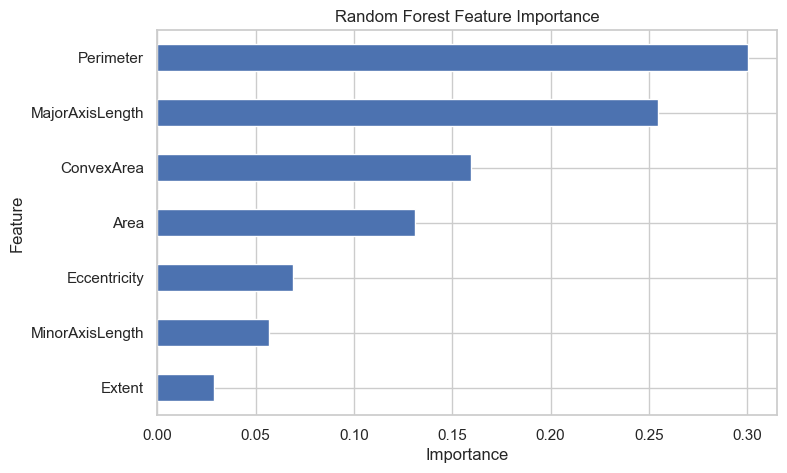

In [114]:
# =========================
# CELL 14: RANDOM FOREST FEATURE IMPORTANCE
# =========================
# Frågeställning:
# Vilka fysiska egenskaper använder Random Forest mest?
#
# Logik:
# Feature importance visar vilka variabler modellen anser mest användbara.
# Detta ger business insight:
# vilka mätvärden är viktigast för automatisk sortering?

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(rf_importance)

plt.figure(figsize=(8, 5))
rf_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Perimeter          0.121667
Extent             0.002778
MajorAxisLength    0.000556
ConvexArea        -0.000278
Eccentricity      -0.000556
MinorAxisLength   -0.004444
Area              -0.006111
dtype: float64

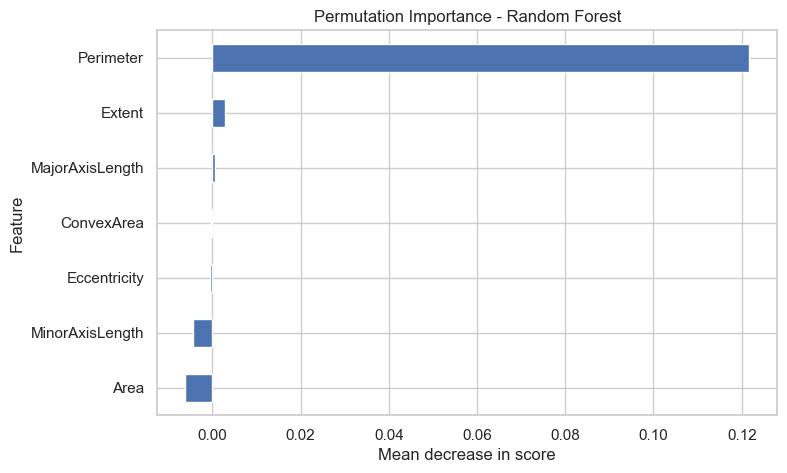

In [115]:
# =========================
# CELL 15: PERMUTATION IMPORTANCE
# =========================
# Frågeställning:
# Vilka features är viktiga när vi testar modellen mer robust?
#
# Logik:
# Vi blandar en kolumn i taget.
# Om modellen blir mycket sämre när en feature blandas,
# betyder det att modellen verkligen behövde den feature.

perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

display(perm_importance)

plt.figure(figsize=(8, 5))
perm_importance.sort_values().plot(kind="barh")
plt.title("Permutation Importance - Random Forest")
plt.xlabel("Mean decrease in score")
plt.ylabel("Feature")
plt.show()

Best parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation F1:
0.8752364240419246
===== Tuned Random Forest =====
Accuracy: 0.8666666666666667
F1-score: 0.8775510204081632
ROC AUC: 0.9196913580246914

Classification report:
              precision    recall  f1-score   support

       Besni       0.95      0.78      0.85        90
     Kecimen       0.81      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



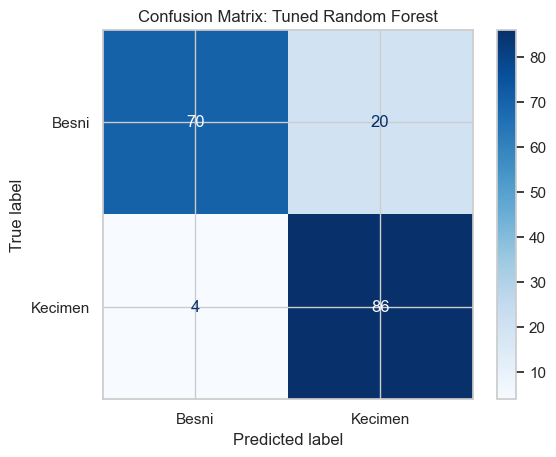

In [116]:
# =========================
# CELL 16: HYPERPARAMETER TUNING - RANDOM FOREST
# =========================
# Frågeställning:
# Kan vi förbättra Random Forest genom att ändra modellens inställningar?
#
# Logik:
# Hyperparametrar är inställningar vi väljer innan träning.
# Exempel:
# - n_estimators = antal träd
# - max_depth = hur djupa träden får bli
# - min_samples_split = hur många observationer som krävs för att dela en nod

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best cross-validation F1:")
print(grid_search.best_score_)

best_rf_model = grid_search.best_estimator_

evaluate_model("Tuned Random Forest", best_rf_model, X_test, y_test)

===== 50 Random Forest =====
Accuracy: 0.8722222222222222
F1-score: 0.882051282051282
ROC AUC: 0.9214197530864198

Classification report:
              precision    recall  f1-score   support

       Besni       0.95      0.79      0.86        90
     Kecimen       0.82      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



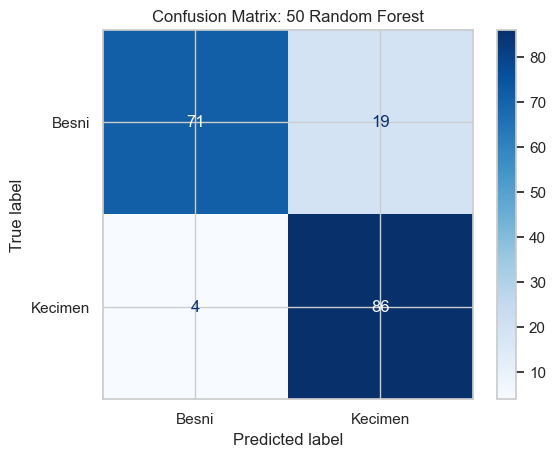

In [117]:
# =========================
# CELL 16.1: SIMPLE 50 RANDOM FOREST
# =========================
# Frågeställning:
# Hur fungerar en enkel och försiktig modell?
#
# Logik:
# Få och grunda träd.
# Mindre risk för överfitting.

simple_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_split=10,
    random_state=42
)

simple_rf.fit(X_train, y_train)

evaluate_model(
    "50 Random Forest",
    simple_rf,
    X_test,
    y_test
)

===== 200 Random Forest =====
Accuracy: 0.8666666666666667
F1-score: 0.8775510204081632
ROC AUC: 0.9215432098765431

Classification report:
              precision    recall  f1-score   support

       Besni       0.95      0.78      0.85        90
     Kecimen       0.81      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



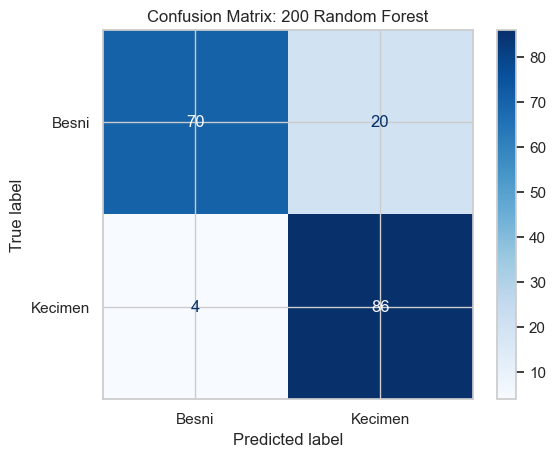

In [118]:
# =========================
# CELL 16.2: MEDIUM 200 RANDOM FOREST
# =========================
# Frågeställning:
# Får vi bättre balans mellan generalisering och komplexitet?

medium_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

medium_rf.fit(X_train, y_train)

evaluate_model(
    "200 Random Forest",
    medium_rf,
    X_test,
    y_test
)

===== 500 Random Forest =====
Accuracy: 0.8611111111111112
F1-score: 0.8717948717948718
ROC AUC: 0.9205555555555556

Classification report:
              precision    recall  f1-score   support

       Besni       0.93      0.78      0.85        90
     Kecimen       0.81      0.94      0.87        90

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.86       180
weighted avg       0.87      0.86      0.86       180



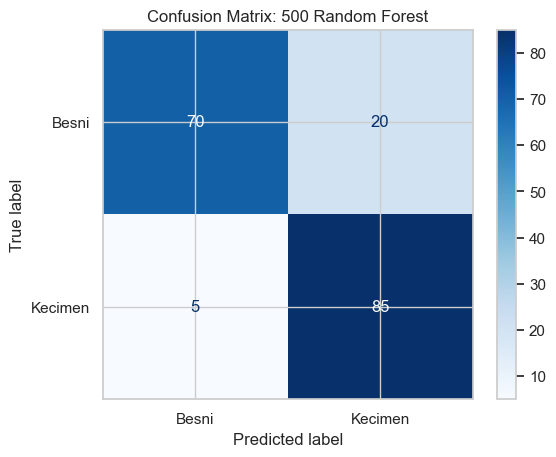

In [119]:
# =========================
# CELL 16.3: COMPLEX 500 RANDOM FOREST
# =========================
# Frågeställning:
# Vad händer om modellen får bli väldigt komplex?
#
# Logik:
# Djupa träd + små splits.
# Risk för överfitting.

complex_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

complex_rf.fit(X_train, y_train)

evaluate_model(
    "500 Random Forest",
    complex_rf,
    X_test,
    y_test
)

In [120]:
# =========================
# CELL 16.4: OVERFITTING CHECK
# =========================

train_score = complex_rf.score(X_train, y_train)
test_score = complex_rf.score(X_test, y_test)

print("Train score:", train_score)
print("Test score:", test_score)

Train score: 1.0
Test score: 0.8611111111111112


===== KNN =====
Accuracy: 0.8166666666666667
F1-score: 0.8290155440414507
ROC AUC: 0.8723456790123457

Classification report:
              precision    recall  f1-score   support

       Besni       0.87      0.74      0.80        90
     Kecimen       0.78      0.89      0.83        90

    accuracy                           0.82       180
   macro avg       0.82      0.82      0.82       180
weighted avg       0.82      0.82      0.82       180



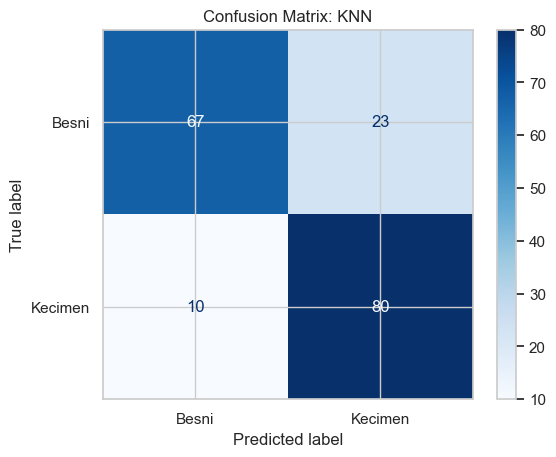

In [121]:
# =========================
# CELL 16.5: KNN CLASSIFIER
# =========================
# Frågeställning:
# Kan russinsorter klassificeras genom likhet?
#
# Logik:
# KNN tittar på närmaste datapunkter i feature-rummet.

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

evaluate_model(
    "KNN",
    knn_model,
    X_test,
    y_test
)

In [122]:
results_df = pd.DataFrame(model_results)

display(results_df.sort_values("f1_score", ascending=False))

,model,accuracy,f1_score,roc_auc
4,Simple Random Forest,0.872222,0.882051,0.921420
21,50 Random Forest,0.872222,0.882051,0.921420
13,50 Random Forest,0.872222,0.882051,0.921420
0,Decision Tree,0.872222,0.879581,0.902963
17,1 Decision Tree,0.872222,0.879581,0.902963
10,200 Random Forest,0.866667,0.877551,0.921543
1,Random Forest,0.866667,0.877551,0.921914
3,Tuned Random Forest,0.866667,0.877551,0.919691
5,Medium Random Forest,0.866667,0.877551,0.921543
18,Random Forest,0.866667,0.877551,0.921914


,model,accuracy,f1_score,roc_auc
4,Simple Random Forest,0.872222,0.882051,0.921420
21,50 Random Forest,0.872222,0.882051,0.921420
13,50 Random Forest,0.872222,0.882051,0.921420
0,Decision Tree,0.872222,0.879581,0.902963
17,1 Decision Tree,0.872222,0.879581,0.902963
10,200 Random Forest,0.866667,0.877551,0.921543
1,Random Forest,0.866667,0.877551,0.921914
3,Tuned Random Forest,0.866667,0.877551,0.919691
5,Medium Random Forest,0.866667,0.877551,0.921543
18,Random Forest,0.866667,0.877551,0.921914


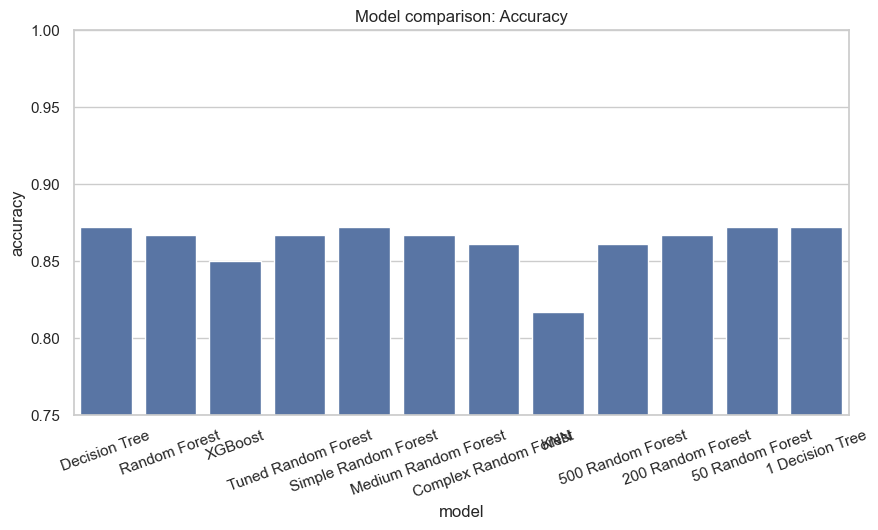

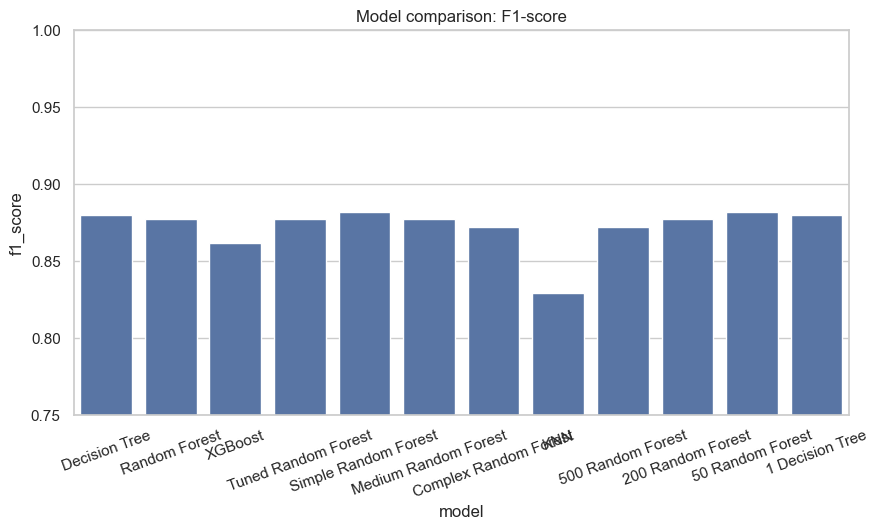

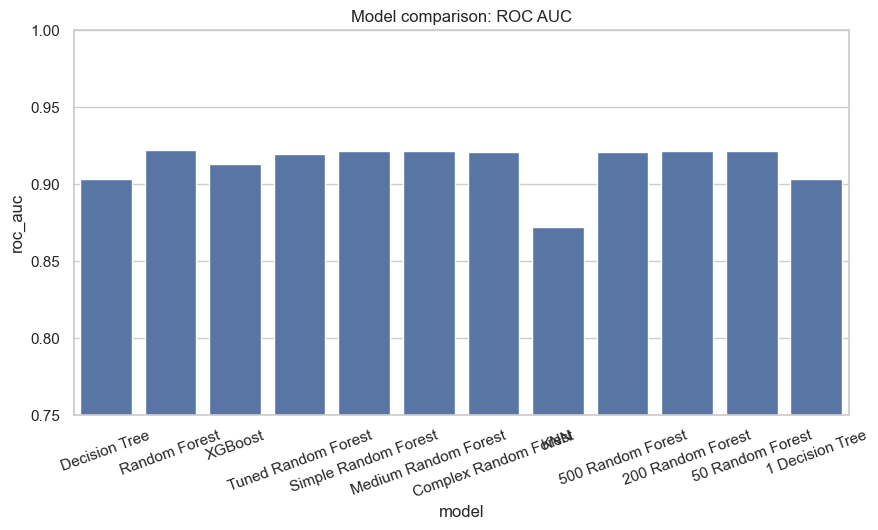

In [123]:
# =========================
# CELL 16.7: MODEL COMPARISON VISUALIZATION
# =========================
# Frågeställning:
# Vilken modell presterade bäst?
#
# Logik:
# Vi jämför:
# - Accuracy
# - F1-score
# - ROC AUC
#
# Detta hjälper oss förstå:
# - vilken modell som generaliserar bäst
# - vilka modeller som verkar överanpassa
# - vilka modeller som är mest stabila

results_df = pd.DataFrame(model_results)

display(results_df.sort_values("f1_score", ascending=False))

# =========================
# Accuracy
# =========================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="model",
    y="accuracy"
)

plt.title("Model comparison: Accuracy")
plt.xticks(rotation=20)
plt.ylim(0.75, 1.0)

plt.show()

# =========================
# F1-score
# =========================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="model",
    y="f1_score"
)

plt.title("Model comparison: F1-score")
plt.xticks(rotation=20)
plt.ylim(0.75, 1.0)

plt.show()

# =========================
# ROC AUC
# =========================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="model",
    y="roc_auc"
)

plt.title("Model comparison: ROC AUC")
plt.xticks(rotation=20)
plt.ylim(0.75, 1.0)

plt.show()

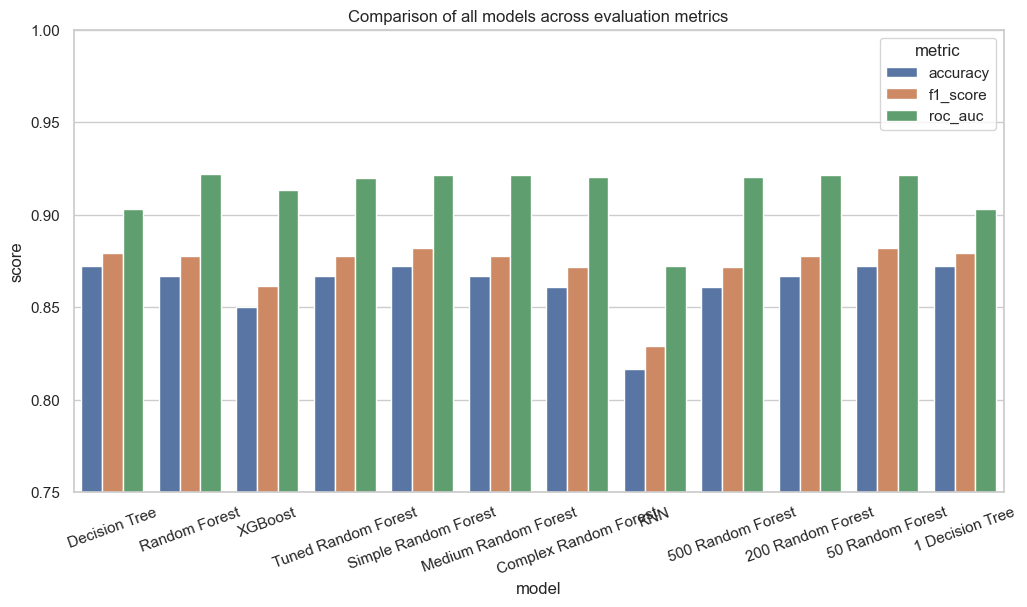

In [124]:
# =========================
# CELL 16.8: ALL METRICS TOGETHER
# =========================
# Frågeställning:
# Hur presterar modellerna över flera metrics samtidigt?
#
# Logik:
# Detta gör det enklare att jämföra modeller direkt.

metrics_melted = results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=metrics_melted,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Comparison of all models across evaluation metrics")
plt.ylim(0.75, 1.0)

plt.xticks(rotation=20)

plt.show()

In [125]:
results_ranked = results_df.sort_values(
    by=["f1_score", "roc_auc"],
    ascending=False
)

display(results_ranked)

,model,accuracy,f1_score,roc_auc
4,Simple Random Forest,0.872222,0.882051,0.921420
13,50 Random Forest,0.872222,0.882051,0.921420
21,50 Random Forest,0.872222,0.882051,0.921420
0,Decision Tree,0.872222,0.879581,0.902963
17,1 Decision Tree,0.872222,0.879581,0.902963
1,Random Forest,0.866667,0.877551,0.921914
18,Random Forest,0.866667,0.877551,0.921914
5,Medium Random Forest,0.866667,0.877551,0.921543
10,200 Random Forest,0.866667,0.877551,0.921543
14,200 Random Forest,0.866667,0.877551,0.921543


Explained variance ratio:
[0.69032694 0.20759835]
Total explained variance: 0.8979252929009324


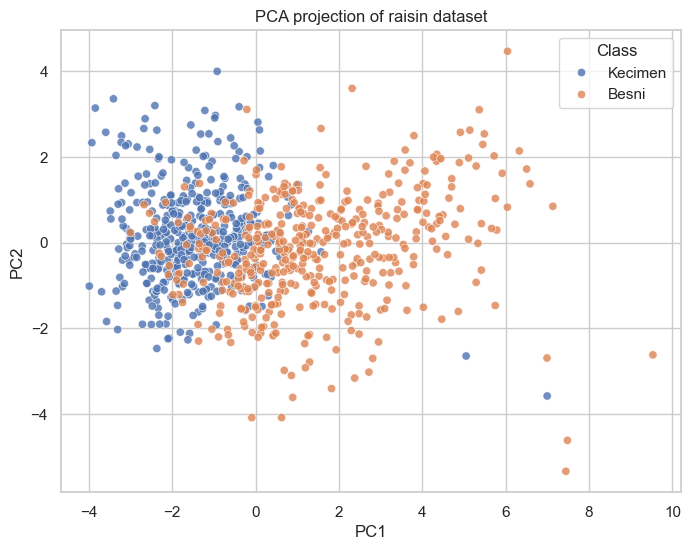

In [126]:
# =========================
# CELL 17: PCA VISUALIZATION
# =========================
# Frågeställning:
# Går russinsorterna att separera visuellt i två dimensioner?
#
# Logik:
# Datasetet har flera features.
# PCA reducerar dessa till två nya axlar:
# PC1 och PC2.
# Om klasserna separeras i PCA-grafen betyder det att russinsorterna
# har olika geometriska profiler.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Class"] = df["Class"]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Class",
    alpha=0.8
)

plt.title("PCA projection of raisin dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

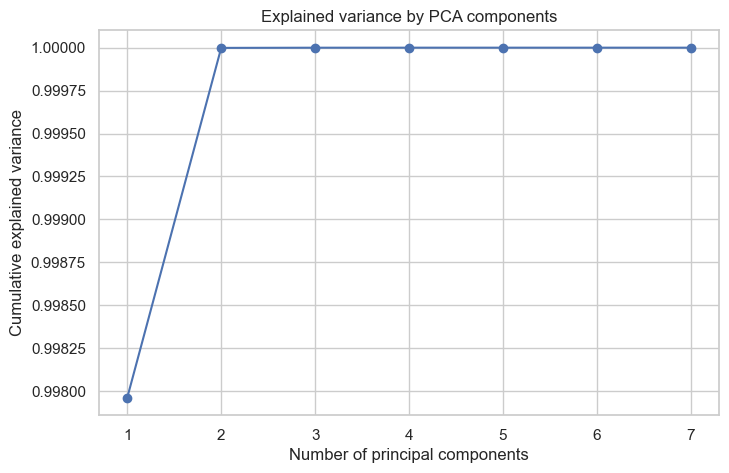

In [127]:
# =========================
# EXTRA: PCA EXPLAINED VARIANCE
# =========================
# Frågeställning:
# Hur mycket information behåller PCA?

pca_full = PCA()

pca_full.fit(X)

explained_variance = pca_full.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")

plt.title("Explained variance by PCA components")

plt.grid(True)

plt.show()

In [128]:
# =========================
# CELL 18: SAVE RESULTS
# =========================
# Syfte:
# Spara modelljämförelsen så gruppen kan använda siffrorna i presentationen.

results_path = project_folder / "results"
results_path.mkdir(exist_ok=True)

results_df.to_csv(results_path / "spirit_model_results.csv", index=False)

print("Saved to:", results_path / "spirit_model_results.csv")

Saved to: c:\Users\spiri\ws\raisin-detective-ml\results\spirit_model_results.csv
